In [1]:
with open('data/links_decoded.tsv', encoding="utf-8", errors="replace") as file:
    data_links_lines = file.readlines()
print(len(data_links_lines))

119894


In [2]:
for item in range(len(data_links_lines[0:15])):
    print(data_links_lines[item],end="")

# The list of all links between articles.
# Article names are URL-encoded; e.g., in Java they can be decoded using java.net.URLDecoder.decode(articleName, "UTF-8").
# FORMAT:   linkSource   linkTarget
#
# When publishing on this data set, please cite:
# (1) Robert West and Jure Leskovec:
#     Human Wayfinding in Information Networks.
#     21st International World Wide Web Conference (WWW), 2012.
# (2) Robert West, Joelle Pineau, and Doina Precup:
#     Wikispeedia: An Online Game for Inferring Semantic Distances between Concepts.
#     21st International Joint Conference on Artificial Intelligence (IJCAI), 2009.

Áedán_mac_Gabráin	Bede
Áedán_mac_Gabráin	Columba
Áedán_mac_Gabráin	Dál_Riata


In [3]:
data_links_lines_cleaned = data_links_lines[12:]
print(data_links_lines_cleaned[0:5])

['Áedán_mac_Gabráin\tBede\n', 'Áedán_mac_Gabráin\tColumba\n', 'Áedán_mac_Gabráin\tDál_Riata\n', 'Áedán_mac_Gabráin\tGreat_Britain\n', 'Áedán_mac_Gabráin\tIreland\n']


In [4]:
raw_links_list = [(link.strip()).split(sep = "\t") for link in data_links_lines_cleaned]
links_list = [{'source':source,'target':target} for source,target in raw_links_list]
print(links_list[0:5])
print(len(links_list))

[{'source': 'Áedán_mac_Gabráin', 'target': 'Bede'}, {'source': 'Áedán_mac_Gabráin', 'target': 'Columba'}, {'source': 'Áedán_mac_Gabráin', 'target': 'Dál_Riata'}, {'source': 'Áedán_mac_Gabráin', 'target': 'Great_Britain'}, {'source': 'Áedán_mac_Gabráin', 'target': 'Ireland'}]
119882


In [5]:
node_degree_dict = {} # initialize the output dictionary

for link in links_list:
    if link['source'] not in node_degree_dict: # first time addition of the source
        node_degree_dict[link['source']] = {'in':0,'out':0} # add the source with 0 counts for in and out
    if link['target'] not in node_degree_dict: # first time addition of the target
        node_degree_dict[link['target']] = {'in':0,'out':0} # add the target with 0 counts for in and out

    node_degree_dict[link['source']]['out'] += 1 # every time the source is found, add 1 to the out count
    node_degree_dict[link['target']]['in'] += 1 # every time the target is found, add 1 to the in count

In [6]:
for key,value in list(node_degree_dict.items())[:5]:
    print(key,value)

Áedán_mac_Gabráin {'in': 0, 'out': 11}
Bede {'in': 27, 'out': 12}
Columba {'in': 13, 'out': 10}
Dál_Riata {'in': 14, 'out': 18}
Great_Britain {'in': 180, 'out': 35}


In [7]:
print(node_degree_dict["Rome"])

{'in': 215, 'out': 71}


In [8]:
max_in = list(node_degree_dict.items())[0] # initialize the variables with the first item in the dictionary to provide challengers
max_out = list(node_degree_dict.items())[0] 
for item in node_degree_dict.items(): # loop through all items in the dictionary
    if item[1]['in'] > max_in[1]['in']: # king of the hill challenge to every item to find the highest "in" count
        max_in = item # assign winner
    if item[1]['out'] > max_out[1]['out']: # king of the hill challenge to every item to find the highest "out" count
        max_out = item # assign winner
print("Highest in-degree article:\n","Name:", max_in[0],"; Values:",max_in[1]) 
print("Highest out-degree article:\n","Name:", max_out[0],"; values:",max_out[1])

Highest in-degree article:
 Name: United_States ; Values: {'in': 1551, 'out': 294}
Highest out-degree article:
 Name: United_States ; values: {'in': 1551, 'out': 294}


In [9]:
total_degree_one_list = [item for item in node_degree_dict.items() if item[1]['in']+item[1]['out'] == 1]

In [30]:
# The get_nodes_with_min_degree function takes a minimum degree number as an argument and returns a list
# of articles names included in the "node_degree_dict"  variable whose total degree value is equal to 
# or greater than the minimum degrees indicated

def get_nodes_with_min_degree(min_degree):

    # creates a list of the items whose total degrees (in + out) is greater than or equal to the argument
    min_degree_list = [node for node, degrees in node_degree_dict.items() if degrees['in']+degrees['out'] >= min_degree]

    return min_degree_list # return the list

len(get_nodes_with_min_degree(500))

20

In [31]:
print(get_nodes_with_min_degree(500))
# In this data, what stands out to me is that the nodes with the highest 
# total degrees seem to all be related to countries, with only a few 
# exceptions on specific themes like World War 2, English Language, 
# Animals or Scientific Classification. Also noticed that none of the 
# countries or regions are from Latin America.

['Russia', 'United_Kingdom', 'World_War_II', 'France', 'Germany', 'Italy', 'Canada', 'English_language', 'England', 'Spain', 'United_States', 'India', 'China', 'Europe', 'Australia', 'Japan', 'London', 'Africa', 'Animal', 'Scientific_classification']


In [12]:
import matplotlib.pyplot as plt

In [32]:
in_degree_list = [degrees['in'] for node, degrees in node_degree_dict.items()]
out_degree_list = [degrees['out'] for node, degrees in node_degree_dict.items()]
# United_States is at index 102, Italy is at 42
print(list(node_degree_dict.items())[102])
print(in_degree_list[102]) 
print(out_degree_list[102])

('United_States', {'in': 1551, 'out': 294})
1551
294


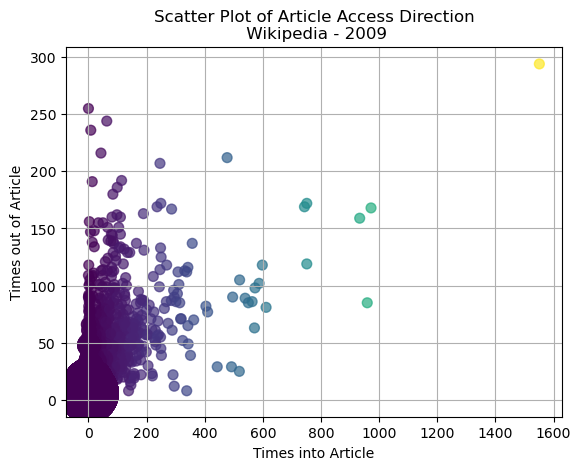

In [14]:
# This first portion allow for sizes to vary based on density or frequency of identical pairs of x,y values

import numpy as np # the numpy library allows to manage array items
from collections import Counter # allows to count the elements of a list

pairs = list(zip(in_degree_list,out_degree_list)) # create a list of all pairs of coordinates
counts = Counter(pairs) # count how many pairs of the same type exist

# assign the counts to each pair coordinate and multiply by 50 for visibility
sizes = np.array([counts[(xi, yi)] for xi, yi in zip(in_degree_list,out_degree_list)])*50 

# This second part is the actual plot, with titles and labels

plt.scatter(in_degree_list,out_degree_list,s=sizes,alpha=0.7,c=in_degree_list) # progressive color with increasing values
plt.grid(True)
plt.title('Scatter Plot of Article Access Direction\n Wikipedia - 2009')
plt.xlabel('Times into Article')
plt.ylabel('Times out of Article')
plt.show() # clean output

In [15]:
total_degree_list = [(degrees['in']+degrees['out']) for node, degrees in node_degree_dict.items() if (degrees['in']+degrees['out']) < 500]

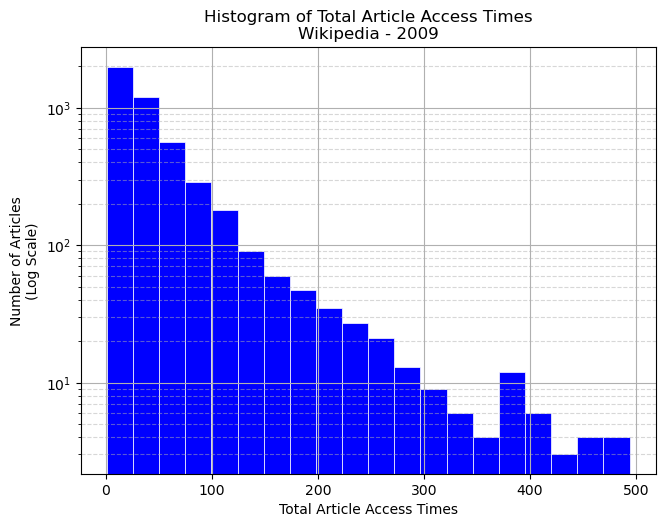

In [33]:
# Plot histogram

plt.hist(total_degree_list, bins = 20, linewidth = 0.5, edgecolor = "white" , facecolor = 'blue', log = True) # logaritmic improves visualization of exponential decline
plt.tight_layout() # avoid label clipping
plt.grid(True) # enhance readability
plt.grid(True, axis = 'y', which='minor', linestyle = '--', alpha = 0.5) # Enhance readability of log scale
plt.title('Histogram of Total Article Access Times\nWikipedia - 2009')
plt.xlabel('Total Article Access Times')
plt.ylabel('Number of Articles\n(Log Scale)')
plt.show() # clean output

In [17]:
# What the data shows is that the article access times are concentrated towards
# the lower bounds. The histogram shows that the access times follows an inverse
# exponential progression (linear in a log scale). It can be concluded that the
# number of articles with a significant amount of access are few, and most articles
# are accessed only a few times. This is also independent of whether the access is
# towards the article or not (as shown by the scatter plot).

In [18]:
import networkx as nx

In [19]:
links_tuple_list = [(link['source'],link['target']) for link in links_list]
graph = nx.DiGraph(links_tuple_list)

In [20]:
import random
random.seed(2614)
sample_node_list = random.sample(list(node_degree_dict.keys()),500)

In [21]:
sample_graph = graph.subgraph(sample_node_list)

In [22]:
path_lengths_dict = dict(nx.all_pairs_shortest_path_length(sample_graph))

In [23]:
print(path_lengths_dict['China']['Rome'])

2


In [34]:
max_distance = 0 # initialize output variables
max_source = None
max_target = None

for source, targets in path_lengths_dict.items():
    for target, distance in targets.items():
        if distance > max_distance: # king of the hill challenge to find the biggest distance
            max_distance = distance
            max_source = source
            max_target = target

print("Source article title:",max_source) 
print("Target article title:",max_target)
print("Distance between articles:",max_distance,"links")

Source article title: Hubbard_Glacier
Target article title: Hurricane_Philippe_(2005)
Distance between articles: 12 links


In [36]:
disconnected_nodes = [] # final list
non_zero_keys_list = [] # needed for comparison

# first loop needed to extract non-zero keys
for path_lengths in path_lengths_dict.values(): # look only at the values 
    for item in list(path_lengths.items()): # generate tuples of the inner dictionaries
        if item[1] > 0: # compare the values of each tuple and filter zero items out
            non_zero_keys_list.append(item[0]) # add all non-zero names (keys)

# second loop to extract all candidate nodes that meet all criteria
for article in path_lengths_dict.items(): 
    node = article[0] # intermediate variable for clarity
    targets = article[1] # intermediate variable for clarity

    # check that the node only lists itself and that the node does not show up in the non-zero list (a target from another node).
    if targets == {node:0} and node not in non_zero_keys_list: 
        disconnected_nodes.append(article) # build the output list

print(disconnected_nodes)

[('Boyle_Roche', {'Boyle_Roche': 0}), ('Albrecht_Rodenbach', {'Albrecht_Rodenbach': 0}), ('Hoover_Dam', {'Hoover_Dam': 0}), ('Flag_of_Australia', {'Flag_of_Australia': 0}), ('United_States_Numbered_Highways', {'United_States_Numbered_Highways': 0}), ('Wright_brothers', {'Wright_brothers': 0}), ('PONG', {'PONG': 0}), ('San_Francisco_garter_snake', {'San_Francisco_garter_snake': 0}), ('Coccinellidae', {'Coccinellidae': 0}), ('Moldovans', {'Moldovans': 0}), ('Jehovah', {'Jehovah': 0}), ('Lighting_designer', {'Lighting_designer': 0}), ('Waheguru', {'Waheguru': 0}), ('Fusarium', {'Fusarium': 0}), ('Cyanocobalamin', {'Cyanocobalamin': 0}), ('Tsar_Bomba', {'Tsar_Bomba': 0}), ('Clone_Wars_(Star_Wars)', {'Clone_Wars_(Star_Wars)': 0}), ('2-6-0', {'2-6-0': 0}), ('Henry_Purcell', {'Henry_Purcell': 0}), ('Lake_Powell', {'Lake_Powell': 0}), ('Pere_Marquette_1225', {'Pere_Marquette_1225': 0}), ('Eastern_Roman_Empire', {'Eastern_Roman_Empire': 0}), ('Worm', {'Worm': 0}), ('M*A*S*H_(TV_series)', {'M*A*

In [26]:
# The function get_neighborhood receives the name of an article as a string and a path distance as a number,
# and returns a list of all articles that are within the specified distance of the article.

def get_neighborhood(article,distance):

    neighborhood_list = [] # initialize the output list
    
    for item in list(path_lengths_dict.items()):
        
        if item[0] == article: # check for distances from the chosen article
            for connection in list(item[1].items()): # loop through all connections to the article
                if connection[1] <= distance: # if the connection distance is less than the specified distance
                    
                    neighborhood_list.append(connection[0]) # append the connection
        
        elif item[1].get(article) != None: # check for distance to the chosen article
            if item[1].get(article) <= distance: # search when the article is within another node in less than the distance steps
            
                neighborhood_list.append(item[0]) # append the other article
    
    return neighborhood_list # return the full articles of interest list

In [27]:
neighborhood = get_neighborhood('Hubbard_Glacier',6)
neighborhood_graph = sample_graph.subgraph(neighborhood)

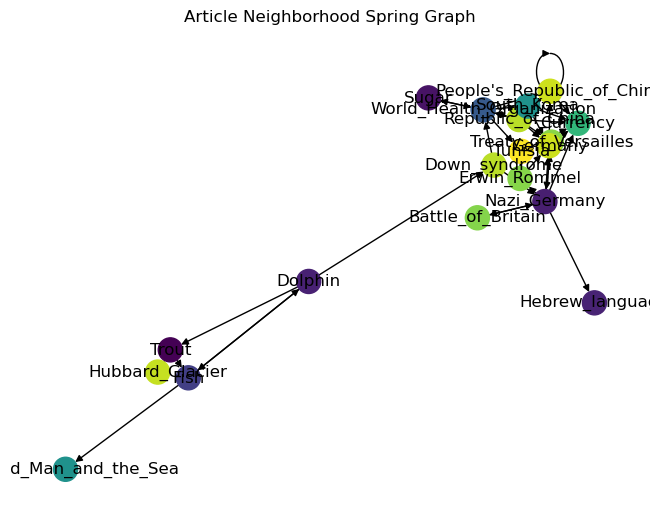

In [28]:
# added a random variable of same length as the graph to the node colors to improve readability.
nx.draw_spring(neighborhood_graph, with_labels=True, node_color=[random.random() for i in range(0,len(neighborhood_graph))])
plt.title('Article Neighborhood Spring Graph')
plt.show()